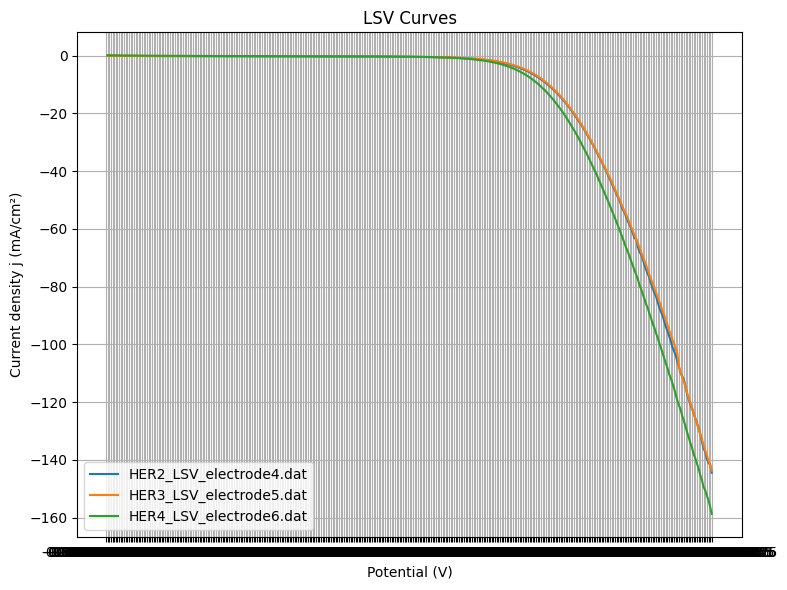

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# -------------------------------------------------------------------
# 1. Load all .dat files in your folder
# -------------------------------------------------------------------
folder_path = r"C:/Users/doaam/Downloads/PhD/virtual_electrochemist/temp_lsv/*.dat"
files = glob.glob(folder_path)

# -------------------------------------------------------------------
# 2. Function to read a single LSV file
# -------------------------------------------------------------------
def read_lsv_file(file_path):
    # Detects whitespace-delimited columns
    df = pd.read_csv(file_path, sep=r"\s+", engine="python", skip_blank_lines=True)

    # Standardize column names
    df.columns = [col.strip() for col in df.columns]

    # Rename columns for convenience
    df = df.rename(columns={
        df.columns[0]: "Potential_V",
        df.columns[1]: "Current_A",
        df.columns[2]: "V_vs_RHE",
        df.columns[3]: "j_mA_cm2",
    })
    return df

# -------------------------------------------------------------------
# 3. Plot all LSV curves
# -------------------------------------------------------------------
plt.figure(figsize=(8, 6))

for file in files:
    df = read_lsv_file(file)

    # Plot: current density j vs potential
    plt.plot(df["Potential_V"], df["j_mA_cm2"], label=file.split("\\")[-1])

plt.xlabel("Potential (V)")
plt.ylabel("Current density j (mA/cm²)")
plt.title("LSV Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
